Part 1: Analysis Tasks (Reliance Industries Limited) The following tasks utilize daily price data for RELIANCE.NS for the past 2 years.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

1. Simple Moving Averages (SMA):
Plot the daily closing price data. Overlay the chart with the 50-day and 200-day simple moving averages (SMA).

/tmp/ipython-input-1165413379.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('RELIANCE.NS', start='2023-12-27', end='2025-12-27')
[*********************100%***********************]  1 of 1 completed


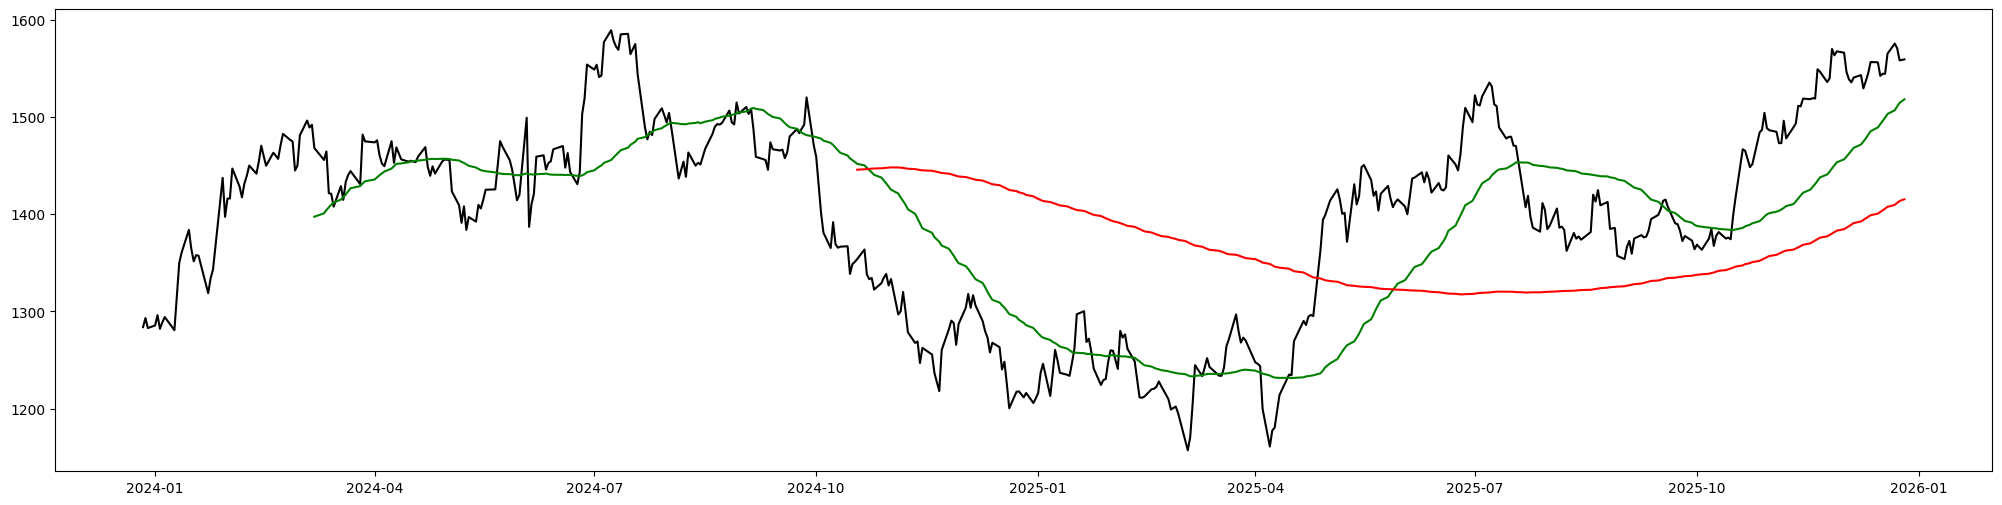

In [2]:
df = yf.download('RELIANCE.NS', start='2023-12-27', end='2025-12-27')

df['sma_50'] = df["Close"].rolling(50).mean()
df['sma_200'] = df["Close"].rolling(200).mean()

plt.figure(figsize=(25,6))
plt.plot(df['Close'],color='black')
plt.plot(df['sma_50'],color='green')
plt.plot(df['sma_200'],color='red')
plt.show()


2. Gap Up and Gap Down Days: Write a program to identify all ”gap up” and ”gap down” days in the stock’s daily price data. Label these points on the closing price chart.





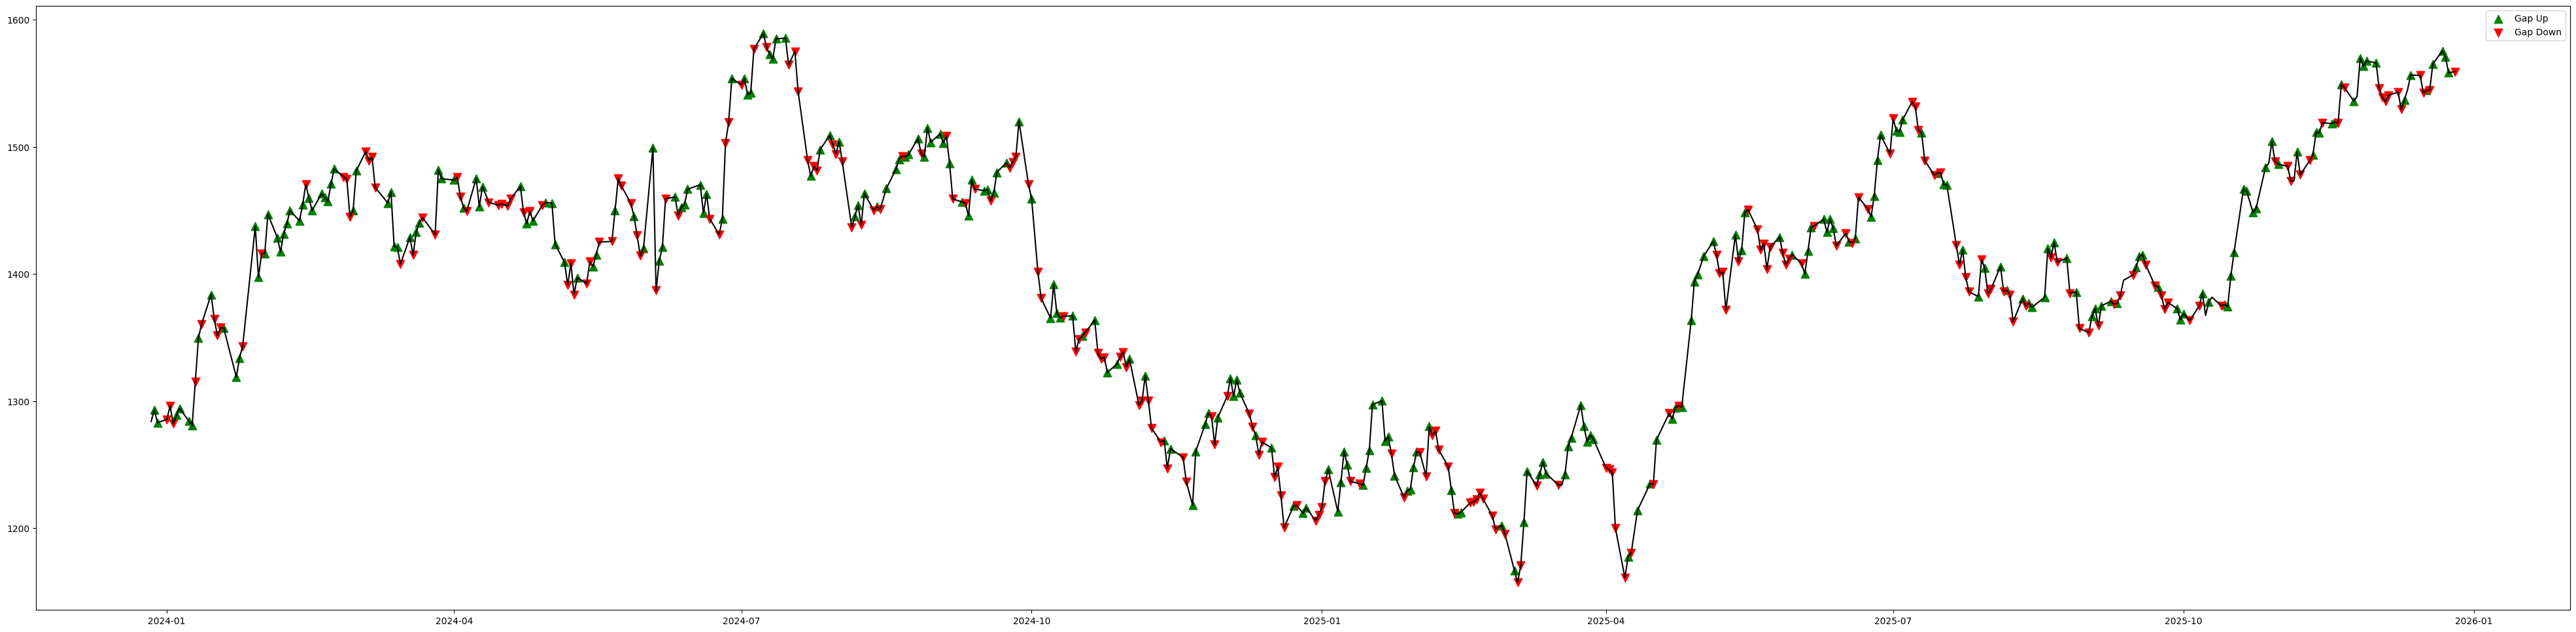

In [3]:
df.columns = df.columns.get_level_values(0)
df['previous_close'] = df['Close'].shift(1)

df["Gap_Up"] = df["Open"]>df['previous_close']
df["Gap_Down"] = df["Open"]<df['previous_close']

plt.figure(figsize=(50,12))
plt.plot(df['Close'],color='black')
plt.scatter(
    df.index[df["Gap_Up"]],
    df["Close"][df["Gap_Up"]],
    color="green",
    marker="^",
    s=80,
    label="Gap Up"
)

plt.scatter(
    df.index[df["Gap_Down"]],
    df["Close"][df["Gap_Down"]],
    color="red",
    marker="v",
    s=80,
    label="Gap Down"
)

plt.legend()
plt.show()


3. Intraday VWAP Calculation:
Fetch intraday price and volume data for the stock. Compute the Volume Weighted Average Price (VWAP) and overlay it on the intraday price chart.


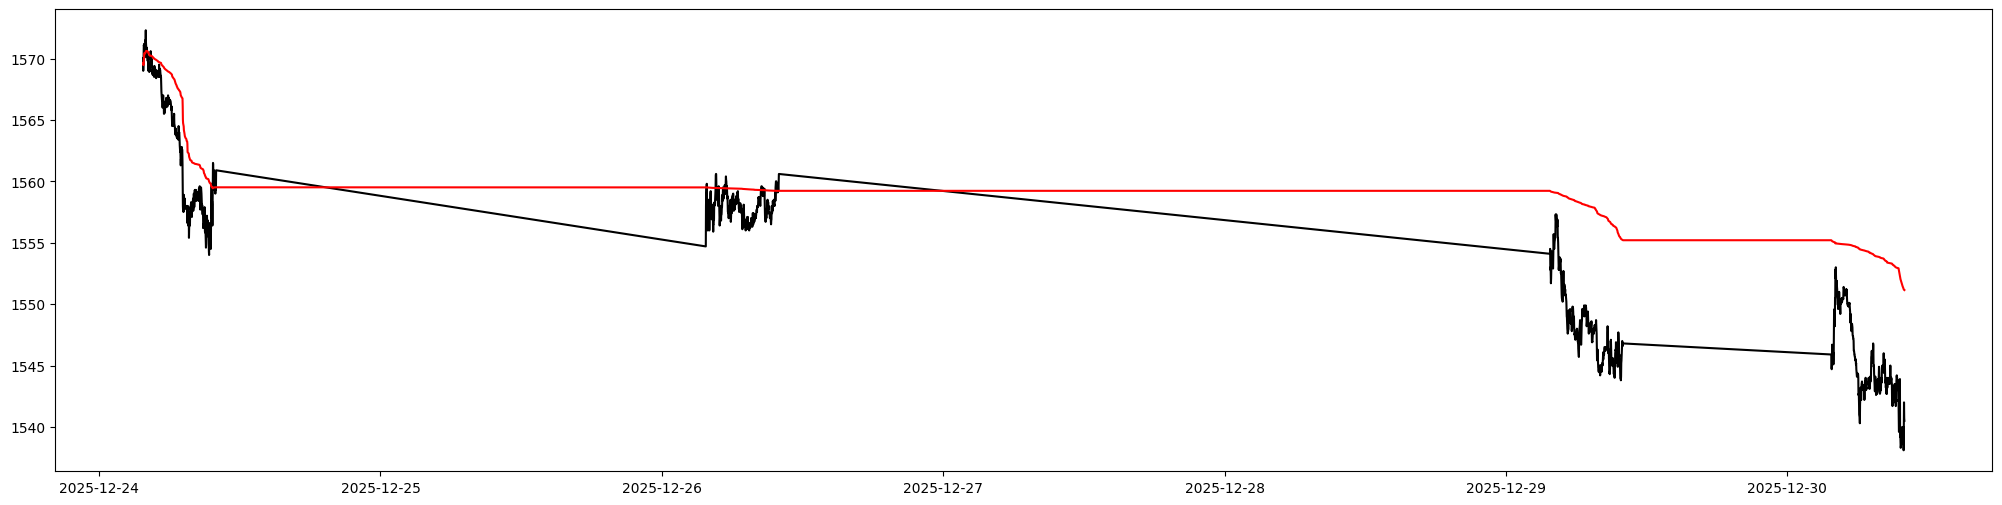

In [4]:
intraday_data = yf.download(tickers='RELIANCE.NS', period="5d", interval="1m", auto_adjust=True, progress=False)
intraday_data.columns = intraday_data.columns.get_level_values(0)



intraday_data['tp'] = (intraday_data['Close']+intraday_data['High']+intraday_data['Low'])/3
intraday_data['tp x vol'] = intraday_data['tp']*intraday_data['Volume']
intraday_data['cumulative_tpxvol'] = intraday_data['tp x vol'].cumsum()
intraday_data['cumulative_vol'] = intraday_data['Volume'].cumsum()
intraday_data['VWAP'] = intraday_data['cumulative_tpxvol']/intraday_data['cumulative_vol']
intraday_data.head()
plt.figure(figsize=(25,6))
plt.plot(intraday_data['Close'], color='black')
plt.plot(intraday_data['VWAP'], color='red')
plt.show()




Part 2: Strategy Development (TCS - 2023)


Question 1: Technical Indicators
Code the following technical indicators as individual functions:
Indicator Category
Volatility & Momentum Trend & Oscillators Price Action
Specific Indicators
Bollinger Bands, Relative Strength Index (RSI) MACD, Average Directional Index (ADX)
Stochastic Oscillator (SO), Average True Range (ATR)

In [14]:
def bollinger_bands(df):
  df['sma']=df['Close'].rolling(20).mean()
  df['sd']=df['Close'].rolling(20).std()
  df['upper_band'] = df['sma'] + 2*df['sd']
  df['lower_band'] = df['sma'] - 2*df['sd']
  return df

def rsi(df, period=14):
  df['diff'] = df['Close'].diff()
  df['Gain'] = (np.where(df['diff'] < 0, 0, df['diff']))
  df['Loss'] = abs(np.where(df['diff'] > 0, 0 , df['diff']))
  df['avg_gain'] = df['Gain'].rolling(period).mean()
  df['avg_loss'] = df['Loss'].rolling(period).mean()
  df['RS'] = df['avg_gain']/df['avg_loss']
  df['RSI'] = 100 - (100/(1+df['RS']))
  return df

def macd(df, short_period=12, long_period=26):
  df['short_ema'] = df['Close'].ewm(short_period).mean()
  df['long_ema'] = df['Close'].ewm(long_period).mean()
  df['macd'] = df['short_ema']-df['long_ema']
  df['signal'] = df['macd'].ewm(9).mean()
  df['macd_signal'] = df['macd']-df['signal']
  return df

def so(df, k_period=12, d_period=9):
  df['lowest_low'] = df['Low'].rolling(k_period).min()
  df['highest_high'] = df['High'].rolling(k_period).max()

  df['%K'] = 100*(df['Close']-df['lowest_low'])/(df['highest_high']-df['lowest_low'])
  df['%D'] = df['%K'].rolling(d_period).mean()

  return df

def atr(df, period=14):
  df['h-l'] = df['High'] - df['Low']
  df['h-prev_close'] = abs(df['High'] - df['Close'].shift(1))
  df['l-prev_close'] = abs(df['Low'] - df['Close'].shift(1))
  df['true_range'] = df[['h-l', 'h-prev_close', 'l-prev_close']].max(axis=1)

  df['ATR'] = df['true_range'].ewm(period).mean()
  return df








Question 2: Signal Generation

In [27]:
def signal_bollinger(df):
  # 1:buy, -1:sell
  df['Signal'] = 0
  df.loc[df['Close'] <= df['lower_band'], 'Signal'] = 1
  df.loc[df['Close'] >= df['upper_band'], 'Signal'] = -1
  print("\nbollinger signals", tcs['Signal'].value_counts())

def signal_rsi(df, oversold_threshold=30, overbought_threshold=70):
  # 1:buy, -1:sell
  df['Signal'] = 0
  df.loc[df['RSI'] <= oversold_threshold, 'Signal'] = 1
  df.loc[df['RSI'] >= overbought_threshold, 'Signal'] = -1
  print("rsi signals", tcs['Signal'].value_counts())

def signal_macd(df):
  # 1:buy, -1:sell
  df['Signal'] = 0
  df.loc[df['macd_signal'] > 0, 'Signal'] = 1
  df.loc[df['macd_signal'] < 0, 'Signal'] = -1
  print("macd signals", tcs['Signal'].value_counts())

def signal_so(df):
  # 1:buy, -1:sell
  df['Signal'] = 0
  df.loc[(df['%K'] > df['%D']) & (df['%K'] > 80), 'Signal'] = 1
  df.loc[(df['%K'] < df['%D']) & (df['%K'] < 20), 'Signal'] = -1
  print("stochastic osc signals", tcs['Signal'].value_counts())






In [28]:
tcs = yf.download("TCS.NS", start="2023-01-01", end="2023-12-31", interval="1d")
tcs.columns = tcs.columns.get_level_values(0)
tcs = bollinger_bands(tcs)
tcs = rsi(tcs)
tcs = macd(tcs)
tcs = so(tcs)
tcs = atr(tcs)

signal_bollinger(tcs)
signal_rsi(tcs)
signal_macd(tcs)
signal_so(tcs)





/tmp/ipython-input-3382030861.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tcs = yf.download("TCS.NS", start="2023-01-01", end="2023-12-31", interval="1d")
[*********************100%***********************]  1 of 1 completed


bollinger signals Signal
 0    225
-1     14
 1      6
Name: count, dtype: int64
rsi signals Signal
 0    183
-1     40
 1     22
Name: count, dtype: int64
macd signals Signal
 1    152
-1     92
 0      1
Name: count, dtype: int64
stochastic osc signals Signal
 0    149
 1     62
-1     34
Name: count, dtype: int64
